In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the original dataset
data = pd.read_csv("../data/smartcare_ai_dataset_1000.csv")

# Handle room_type for visualization
data["room_type"] = data["room_type"].fillna("Unknown")

print("Dataset shape:", data.shape)

Dataset shape: (1000, 33)


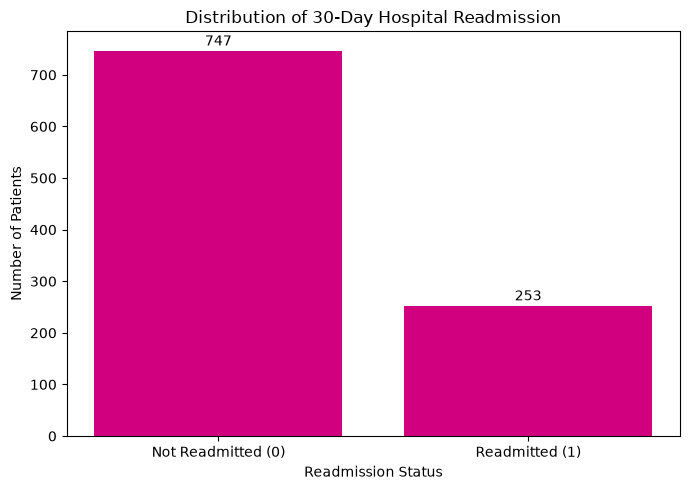

In [3]:
target_counts = data["readmitted_30_days"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Not Readmitted (0)", "Readmitted (1)"],
    target_counts.values,
    color="#D1007F"
)

plt.title("Distribution of 30-Day Hospital Readmission")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")

for i, value in enumerate(target_counts.values):
    plt.text(i, value + 10, str(value), ha="center")

plt.tight_layout()
plt.show()

## 4.2 Target Variable Distribution

The target variable `readmitted_30_days` was visualized to understand the distribution of patients according to their 30-day readmission status. The dataset contains both readmitted and non-readmitted patients, with non-readmitted patients representing the majority of the observations.

This distribution indicates a moderate class imbalance. Therefore, model performance will later be evaluated using multiple metrics rather than accuracy alone.

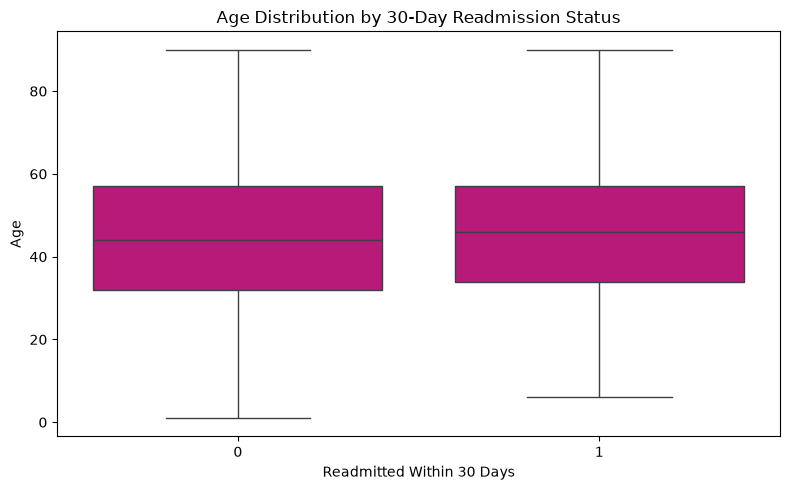

In [4]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="readmitted_30_days",
    y="age",
    color="#D1007F"
)

plt.title("Age Distribution by 30-Day Readmission Status")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [5]:
data.groupby("readmitted_30_days")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
readmitted_30_days,,,,,,,,
0,747.0,44.388220,18.247825,1.0,32.0,44.0,57.0,90.0
1,253.0,45.794466,16.616271,6.0,34.0,46.0,57.0,90.0


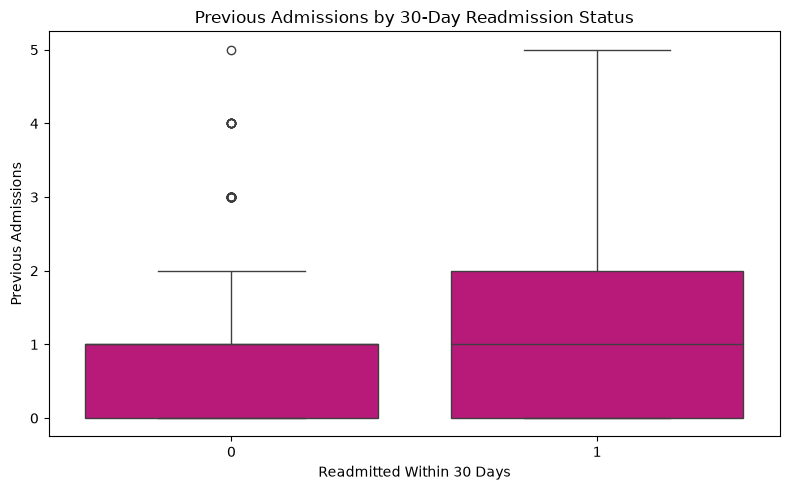

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="readmitted_30_days",
    y="previous_admissions",
    color="#D1007F"
)

plt.title("Previous Admissions by 30-Day Readmission Status")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Previous Admissions")

plt.tight_layout()
plt.show()

In [7]:
data.groupby("readmitted_30_days")["previous_admissions"].describe()

,count,mean,std,min,25%,50%,75%,max
readmitted_30_days,,,,,,,,
0,747.0,0.819277,0.910618,0.0,0.0,1.0,1.0,5.0
1,253.0,0.960474,1.083067,0.0,0.0,1.0,2.0,5.0


In [8]:
print("AGE ANALYSIS")
print(data["age"].describe())

AGE ANALYSIS
count    1000.000000
mean       44.744000
std        17.851474
min         1.000000
25%        33.000000
50%        44.000000
75%        57.000000
max        90.000000
Name: age, dtype: float64


In [9]:
print("\nAGE BY READMISSION")
print(data.groupby("readmitted_30_days")["age"].describe())


AGE BY READMISSION
                    count       mean        std  min   25%   50%   75%   max
readmitted_30_days                                                          
0                   747.0  44.388220  18.247825  1.0  32.0  44.0  57.0  90.0
1                   253.0  45.794466  16.616271  6.0  34.0  46.0  57.0  90.0


In [10]:
print(data[["age", "previous_admissions", "readmitted_30_days"]].head(10))

   age  previous_admissions  readmitted_30_days
0   53                    1                   0
1   26                    0                   0
2   22                    1                   0
3   44                    0                   0
4   51                    1                   0
5   50                    0                   1
6   21                    0                   0
7   64                    1                   0
8   53                    0                   0
9   51                    1                   0


In [11]:
age_analysis = data.groupby("readmitted_30_days")["age"].describe()

age_analysis

,count,mean,std,min,25%,50%,75%,max
readmitted_30_days,,,,,,,,
0,747.0,44.388220,18.247825,1.0,32.0,44.0,57.0,90.0
1,253.0,45.794466,16.616271,6.0,34.0,46.0,57.0,90.0


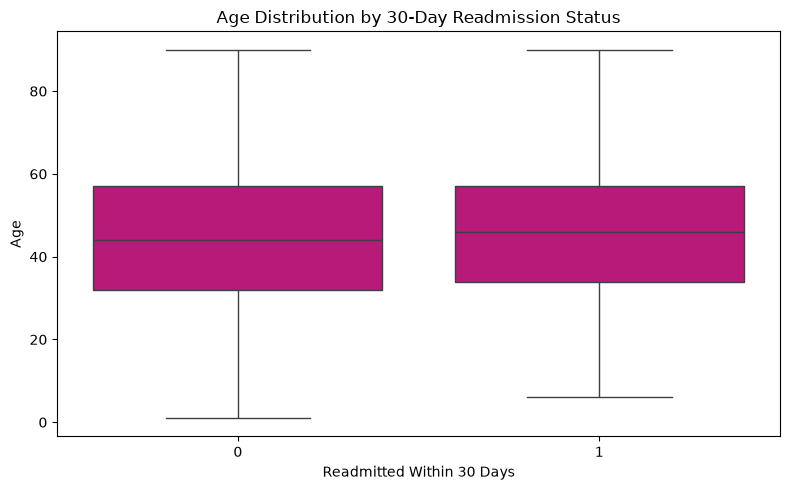

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="readmitted_30_days",
    y="age",
    color="#D1007F"
)

plt.title("Age Distribution by 30-Day Readmission Status")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

## 4.3 Age and 30-Day Readmission

The relationship between patient age and 30-day readmission was explored using descriptive statistics and a boxplot. Patients were divided into two groups based on the `readmitted_30_days` target variable: patients who were not readmitted (`0`) and patients who were readmitted (`1`).

The descriptive statistics and visualization were used to compare the age distributions between the two groups. The analysis helps identify whether age shows an observable difference between readmitted and non-readmitted patients.

Age was therefore retained as a potential predictive feature for the subsequent machine learning stage. However, the exploratory analysis alone does not establish a causal relationship between age and readmission; its predictive importance will be evaluated later using the trained machine learning models.


In [13]:
previous_admission_analysis = data.groupby(
    "readmitted_30_days"
)["previous_admissions"].describe()

previous_admission_analysis

,count,mean,std,min,25%,50%,75%,max
readmitted_30_days,,,,,,,,
0,747.0,0.819277,0.910618,0.0,0.0,1.0,1.0,5.0
1,253.0,0.960474,1.083067,0.0,0.0,1.0,2.0,5.0


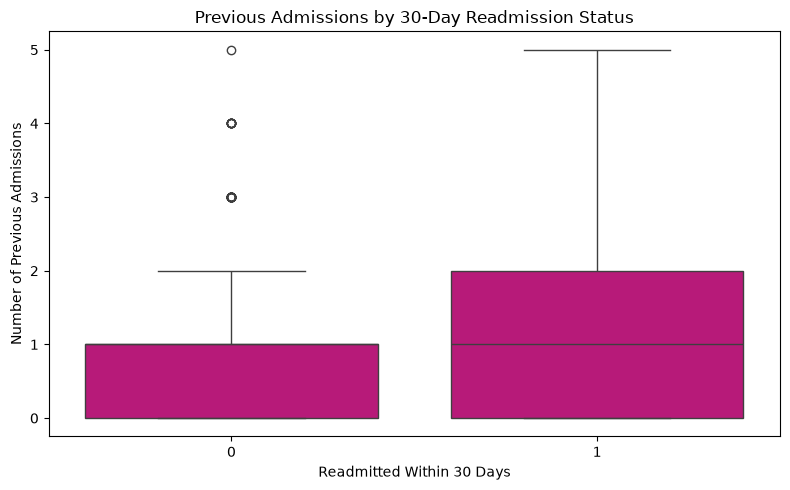

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="readmitted_30_days",
    y="previous_admissions",
    color="#D1007F"
)

plt.title("Previous Admissions by 30-Day Readmission Status")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Previous Admissions")

plt.tight_layout()
plt.show()

## 4.4 Previous Admissions and 30-Day Readmission

The relationship between the number of previous hospital admissions and 30-day readmission was examined using a boxplot.

The visualization shows that patients who were readmitted within 30 days generally have a somewhat higher distribution of previous admissions compared with patients who were not readmitted. The median for the readmitted group is approximately one previous admission, while the non-readmitted group is concentrated more strongly around zero to one previous admission.

The readmitted group also contains observations extending to five previous admissions, suggesting that some patients with a greater history of hospital admissions experienced 30-day readmission.

This observation suggests that previous admission history may contain useful predictive information for the readmission model. However, this exploratory relationship does not establish causation, and the actual predictive contribution of the feature will be evaluated during model training and feature analysis.

In [15]:
length_of_stay_analysis = data.groupby(
    "readmitted_30_days"
)["length_of_stay_days"].describe()

length_of_stay_analysis

,count,mean,std,min,25%,50%,75%,max
readmitted_30_days,,,,,,,,
0,747.0,0.297189,1.005364,0.0,0.0,0.0,0.0,6.0
1,253.0,3.482213,1.867825,1.0,2.0,3.0,5.0,9.0


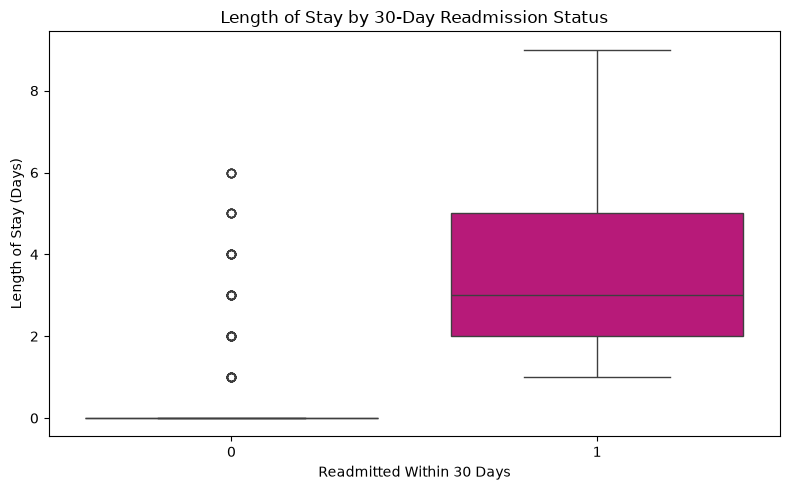

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="readmitted_30_days",
    y="length_of_stay_days",
    color="#D1007F"
)

plt.title("Length of Stay by 30-Day Readmission Status")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Length of Stay (Days)")

plt.tight_layout()
plt.show()

## 4.5 Length of Stay and 30-Day Readmission

The relationship between hospital length of stay and 30-day readmission was investigated using descriptive statistics and a boxplot.

A noticeable difference was observed between the two groups. Patients who were not readmitted had an average length of stay of approximately 0.30 days, with a median of 0 days. In comparison, patients who were readmitted had an average length of stay of approximately 3.48 days and a median of 3 days.

The readmitted group also had a wider range of hospital stays, with values extending up to 9 days, while the maximum observed stay among non-readmitted patients was 6 days.

These results indicate that length of stay shows a potentially strong association with 30-day readmission in the dataset and may provide useful predictive information for the machine learning models. Since the proposed prediction point is at discharge, length of stay is considered available information at the time of prediction.

However, the exploratory analysis demonstrates association rather than causation. The actual predictive contribution of this feature will be evaluated during model training and interpretation.

In [17]:
department_readmission = pd.crosstab(
    data["department"],
    data["readmitted_30_days"],
    normalize="index"
) * 100

department_readmission

readmitted_30_days,0,1
department,,
Cardiology,73.417722,26.582278
General Medicine,81.761006,18.238994
Laboratory Services,76.724138,23.275862
Neurology,74.324324,25.675676
Orthopedics,75.177305,24.822695
Pediatrics,71.739130,28.260870
Radiology,69.285714,30.714286


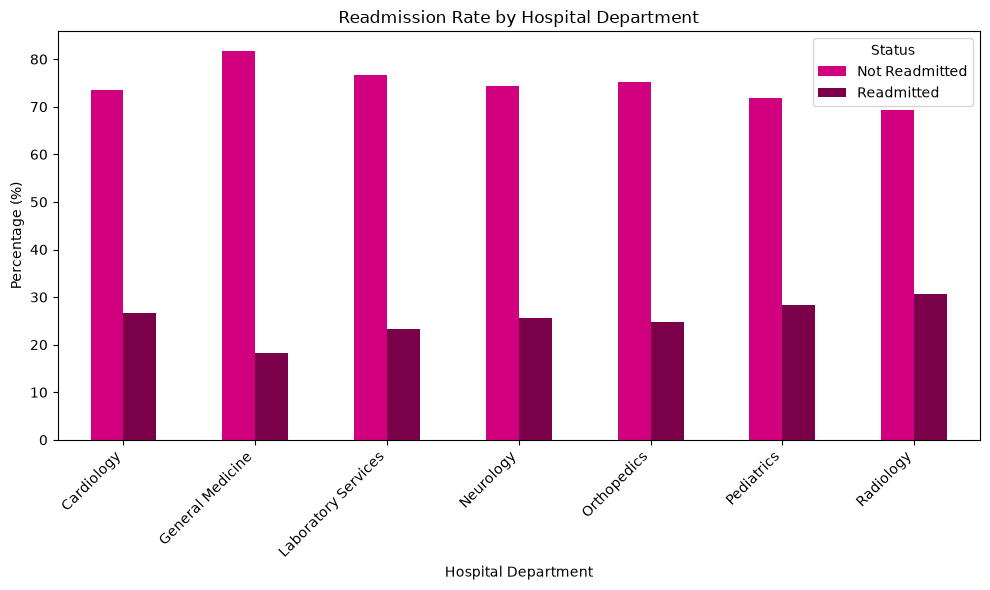

In [18]:
department_readmission.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#D1007F", "#7A004A"]
)

plt.title("Readmission Rate by Hospital Department")
plt.xlabel("Hospital Department")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(
    ["Not Readmitted", "Readmitted"],
    title="Status"
)

plt.tight_layout()
plt.show()

## 4.6 Department and 30-Day Readmission

The relationship between hospital department and 30-day readmission was examined by calculating the percentage of readmitted and non-readmitted patients within each department.

The observed readmission rates varied across departments. Radiology had the highest observed readmission rate at 30.71%, followed by Pediatrics at 28.26% and Cardiology at 26.58%. General Medicine had the lowest observed readmission rate at 18.24%.

These differences indicate that the hospital department may contain useful information for predicting 30-day readmission. However, the observed differences represent associations within the dataset and should not be interpreted as evidence that department directly causes readmission. The predictive contribution of the department variable will be assessed during machine learning model development.

In [19]:
diagnosis_readmission = pd.crosstab(
    data["diagnosis"],
    data["readmitted_30_days"],
    normalize="index"
) * 100

diagnosis_readmission

readmitted_30_days,0,1
diagnosis,,
Asthma,67.391304,32.608696
Back Pain,78.846154,21.153846
Chest Pain,64.367816,35.632184
Diabetes,78.350515,21.649485
Fever,73.831776,26.168224
Fracture,79.807692,20.192308
Hypertension,82.022472,17.977528
Kidney Infection,76.237624,23.762376
Migraine,74.038462,25.961538


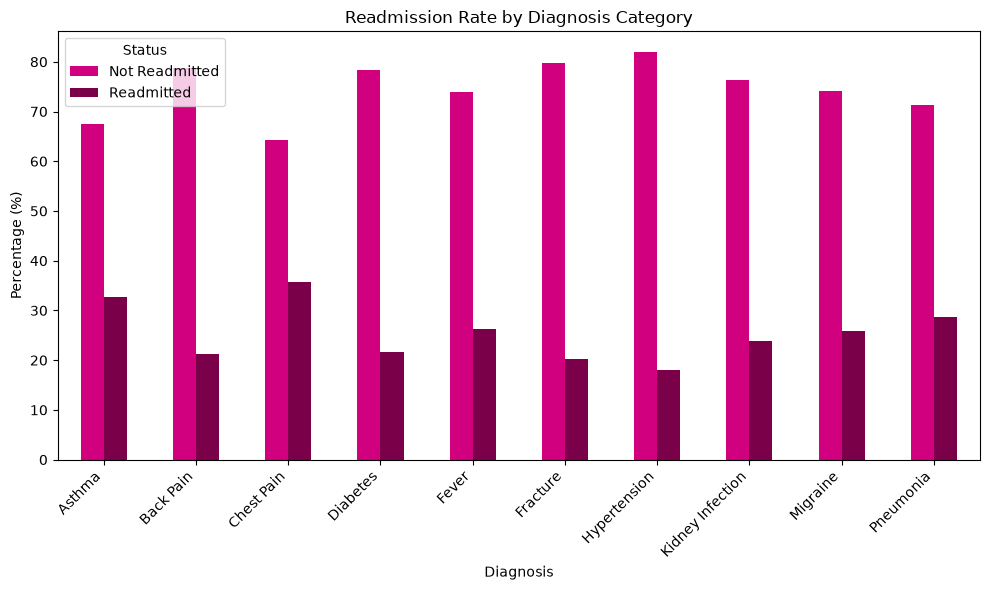

In [20]:
diagnosis_readmission.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#D1007F", "#7A004A"]
)

plt.title("Readmission Rate by Diagnosis Category")
plt.xlabel("Diagnosis")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(
    ["Not Readmitted", "Readmitted"],
    title="Status"
)

plt.tight_layout()
plt.show()

## 4.7 Diagnosis and 30-Day Readmission

The relationship between the primary diagnosis category and 30-day readmission was investigated by calculating the percentage of readmitted and non-readmitted patients within each diagnosis category.

The observed readmission rates varied considerably across diagnosis categories. Chest Pain had the highest observed readmission rate at 35.63%, followed by Asthma at 32.61% and Pneumonia at 28.70%. In contrast, Hypertension had the lowest observed readmission rate at 17.98%, followed by Fracture at 20.19% and Back Pain at 21.15%.

These differences suggest that the primary diagnosis may provide useful predictive information for 30-day readmission. However, these results represent descriptive associations within the dataset and do not establish a causal relationship. The predictive importance of diagnosis will be evaluated through the machine learning models.

In [21]:
clinical_features = [
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar_mg_dl",
    "cholesterol_mg_dl",
    "bmi"
]

clinical_analysis = data.groupby(
    "readmitted_30_days"
)[clinical_features].mean()

clinical_analysis

,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi
readmitted_30_days,,,,,
0,128.182062,78.836680,115.132530,204.247657,25.486212
1,129.134387,78.802372,113.944664,206.486166,25.616206


In [22]:
clinical_medians = data.groupby(
    "readmitted_30_days"
)[clinical_features].median()

clinical_medians

,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi
readmitted_30_days,,,,,
0,128.0,79.0,114.0,204.0,25.6
1,129.0,79.0,113.0,208.0,25.4


## 4.8 Clinical Measurements and 30-Day Readmission

The clinical measurements systolic blood pressure, diastolic blood pressure, blood sugar, cholesterol, and BMI were compared between patients who were and were not readmitted within 30 days.

The mean and median values for the two groups were generally similar. Systolic blood pressure was slightly higher among readmitted patients, while diastolic blood pressure showed almost no difference. Blood sugar was slightly lower among the readmitted group. Cholesterol was somewhat higher among readmitted patients, while BMI showed very similar values between the two groups.

Overall, the descriptive statistics do not show large differences in these clinical measurements between the two readmission groups. However, this does not mean that these features have no predictive value. Machine learning models may identify nonlinear relationships or interactions that are not apparent from simple descriptive statistics.

In [23]:
numerical_columns = data.select_dtypes(
    include=["int64", "float64"]
).columns

correlation_matrix = data[numerical_columns].corr()

correlation_matrix["readmitted_30_days"].sort_values(
    ascending=False
)

readmitted_30_days              1.000000
admitted                        0.829240
length_of_stay_days             0.734844
total_bill_lkr                  0.453418
medicine_charge_lkr             0.402495
treatments_count                0.386763
lab_tests_count                 0.367357
lab_charge_lkr                  0.322054
room_charge_lkr                 0.270538
previous_admissions             0.064067
age                             0.034263
record_id                       0.029622
systolic_bp                     0.026746
cholesterol_mg_dl               0.026569
no_show                         0.026523
waiting_days                    0.014947
consultation_fee_lkr            0.013499
bmi                             0.013295
diastolic_bp                   -0.001486
previous_appointments          -0.018554
blood_sugar_mg_dl              -0.019859
missed_previous_appointments   -0.052581
Name: readmitted_30_days, dtype: float64

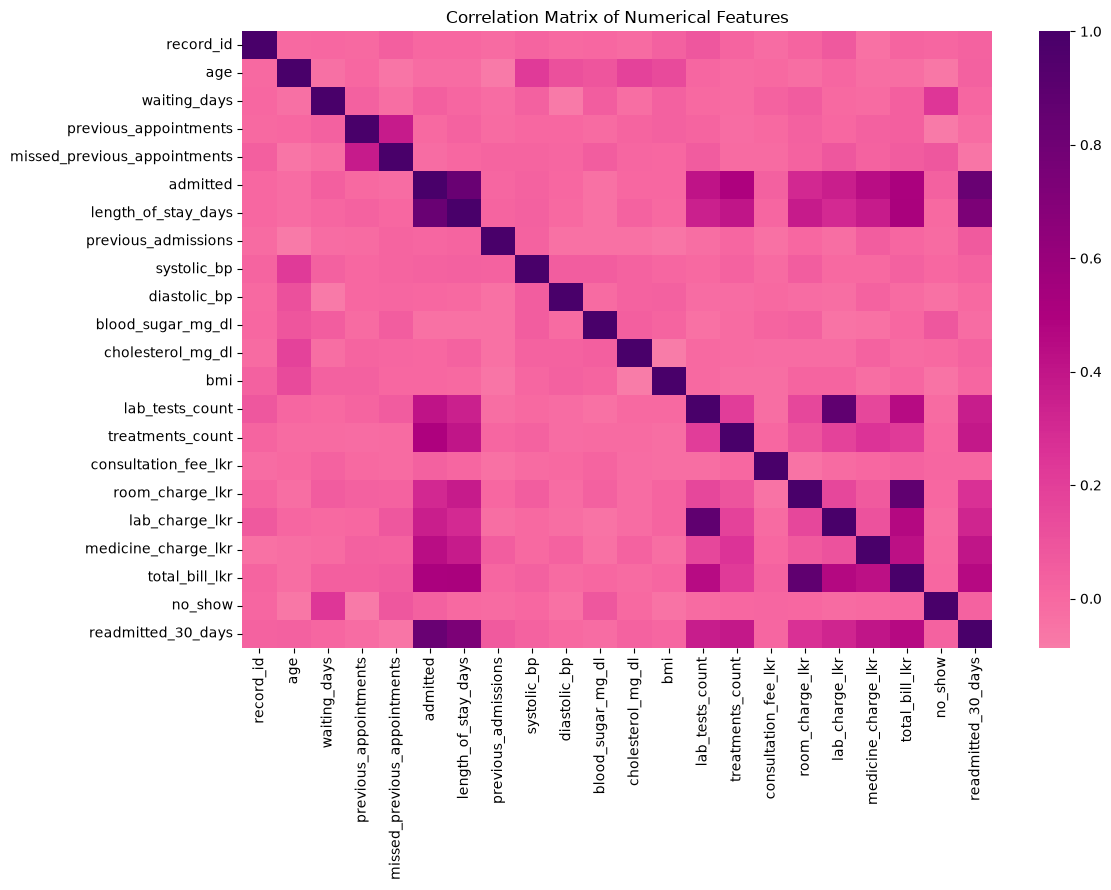

In [24]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    cmap="RdPu",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [25]:
correlation_with_target = (
    correlation_matrix["readmitted_30_days"]
    .sort_values(ascending=False)
)

correlation_with_target

readmitted_30_days              1.000000
admitted                        0.829240
length_of_stay_days             0.734844
total_bill_lkr                  0.453418
medicine_charge_lkr             0.402495
treatments_count                0.386763
lab_tests_count                 0.367357
lab_charge_lkr                  0.322054
room_charge_lkr                 0.270538
previous_admissions             0.064067
age                             0.034263
record_id                       0.029622
systolic_bp                     0.026746
cholesterol_mg_dl               0.026569
no_show                         0.026523
waiting_days                    0.014947
consultation_fee_lkr            0.013499
bmi                             0.013295
diastolic_bp                   -0.001486
previous_appointments          -0.018554
blood_sugar_mg_dl              -0.019859
missed_previous_appointments   -0.052581
Name: readmitted_30_days, dtype: float64

## 4.9 Correlation Analysis

Pearson correlation was used to examine the linear relationships between numerical variables and the `readmitted_30_days` target.

The strongest positive correlations with 30-day readmission were observed for `admitted` (0.8292) and `length_of_stay_days` (0.7348). Moderate positive correlations were also observed for `total_bill_lkr` (0.4534), `medicine_charge_lkr` (0.4025), `treatments_count` (0.3868), and `lab_tests_count` (0.3674).

In contrast, demographic and clinical measurements such as age, BMI, systolic blood pressure, diastolic blood pressure, and blood sugar showed relatively weak linear correlations with the target.

Correlation measures only linear association and does not determine causation or overall predictive importance. Therefore, these findings will be further investigated during model development and feature interpretation.

A particularly strong relationship was observed for `admitted` and `length_of_stay_days`. These variables will be reviewed in relation to the intended prediction point to ensure that information occurring after the prediction time does not introduce temporal data leakage.

# 4.10 Summary of Exploratory Data Analysis

The exploratory data analysis identified several patterns within the SmartCare AI dataset.

The target variable `readmitted_30_days` contained 74.7% non-readmitted patients and 25.3% readmitted patients, indicating a moderate class imbalance.

Previous admissions showed a small positive association with 30-day readmission. A stronger difference was observed for hospital length of stay, where readmitted patients had a mean stay of approximately 3.48 days compared with 0.30 days among non-readmitted patients.

Readmission rates also varied across hospital departments. Radiology had the highest observed readmission rate at 30.71%, while General Medicine had the lowest at 18.24%.

Diagnosis categories also showed differences in readmission rates. Chest Pain had the highest observed rate at 35.63%, followed by Asthma at 32.61%.

The clinical measurements examined, including blood pressure, blood sugar, cholesterol, and BMI, showed relatively similar mean and median values between the two readmission groups.

Correlation analysis identified `admitted` and `length_of_stay_days` as the strongest numerical relationships with the target, with correlation coefficients of 0.8292 and 0.7348 respectively. Other moderately correlated variables included total bill, medicine charges, treatment count, and laboratory test count.

These findings provide useful insights for feature selection and model development. However, correlation and exploratory analysis do not establish causation or guarantee predictive importance. The final contribution of each feature will be assessed through machine learning model evaluation and explainability techniques.